In [1]:
import gen
import networkx as nx
import os


## Initial setup and importing a reference genome

Open or create a repository and set up a context for operations that write to the database. (In future versions this will be handled transparently.)

In [7]:
repo = gen.Repository()
ctx = gen.DbContext()

print(f"The repository currently houses {len(repo.get_block_groups())} sequence graphs")

The repository currently houses 0 sequence graphs


Import a reference sequence, the name will be extracted from the fasta header and no sample is created since this is our reference.

In [8]:
gen.import_fasta(ctx, '../../fixtures/simple.fa')

Fasta import called


'Fasta imported.'

In [9]:
print(f"The repository currently houses {len(repo.get_block_groups())} sequence graphs")

The repository currently houses 1 sequence graphs


## Applying variants obtained from sequencing

In [11]:
gen.update_with_vcf(ctx, '../../fixtures/simple.vcf')


Update with VCF called


'Updated with VCF.'

This operation creates new samples, using the names from the vcf file:

In [12]:
[bg.sample_name for bg in repo.get_block_groups() if bg.sample_name]

['unknown', 'G1', 'foo']

Variants result in an expansion of the graphs.

In [13]:
bg = [bg for bg in repo.get_block_groups() if bg.sample_name == 'foo'][0]

[f"sample {bg.sample_name}: {len(repo.block_group_to_networkx(bg).nodes())} blocks" for bg in repo.get_block_groups() if bg.sample_name]

['sample unknown: 7 blocks', 'sample G1: 3 blocks', 'sample foo: 5 blocks']

## Visualizing a complex graph

In [15]:
gen.import_gfa(ctx, '../../fixtures/anderson_promoters.gfa', sample='library')

GFA import called


'GFA imported.'

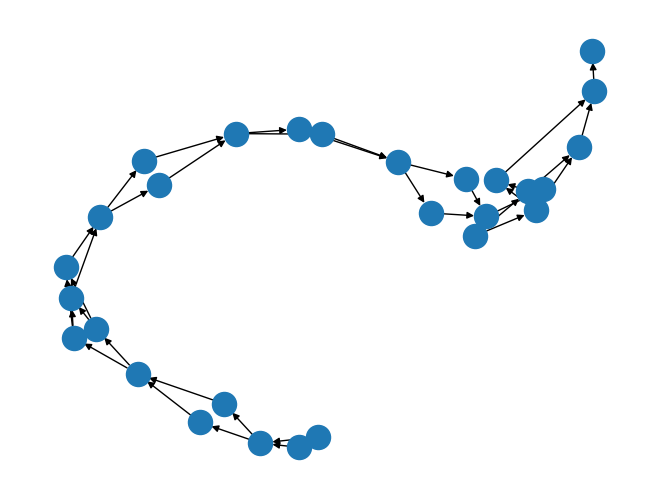

In [16]:
bg = [bg for bg in repo.get_block_groups() if bg.sample_name == 'library'][0]
G = repo.block_group_to_networkx(bg)
nx.draw(G)

pos = nx.nx_agraph.graphviz_layout(G,prog='neato')
nx.draw(G, pos=pos)